# Student Performance Analysis
---
## Project Overview

This notebook implements a Stacking Ensemble approach to predict student academic performance (final grades) using demographic, social, and academic factors. The model achieves:

- 86.19% R² score for Portuguese course
- 82.43% R² score for Mathematics course

---

## 1. Import Required Libraries

We use scikit-learn for machine learning, pandas for data manipulation, and matplotlib/seaborn for visualizations.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor
from sklearn.svm import SVR
from sklearn.linear_model import Ridge, Lasso, LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split, KFold
import xgboost as xgb
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
plt.style.use('default')
sns.set_palette("husl")

np.random.seed(42)
import random
random.seed(42)

print("All libraries imported successfully")
print("Random seed set to 42 for reproducibility")

All libraries imported successfully


## 3. Data Loading and Exploration

In [4]:
def load_data(filepath):
    df = pd.read_csv(filepath)
    print(f"\nLoaded {filepath}")
    print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
    return df

df_portuguese = load_data('student-por.csv')
df_math = load_data('student-mat.csv')

print("\nSample Data (Portuguese):")
display(df_portuguese.head())

print("\nColumn Information:")
print(df_portuguese.info())


Loaded student-por.csv
Shape: 649 rows × 33 columns

Loaded student-mat.csv
Shape: 395 rows × 33 columns

Sample Data (Portuguese):


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13



Column Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      649 non-null    object
 1   sex         649 non-null    object
 2   age         649 non-null    int64 
 3   address     649 non-null    object
 4   famsize     649 non-null    object
 5   Pstatus     649 non-null    object
 6   Medu        649 non-null    int64 
 7   Fedu        649 non-null    int64 
 8   Mjob        649 non-null    object
 9   Fjob        649 non-null    object
 10  reason      649 non-null    object
 11  guardian    649 non-null    object
 12  traveltime  649 non-null    int64 
 13  studytime   649 non-null    int64 
 14  failures    649 non-null    int64 
 15  schoolsup   649 non-null    object
 16  famsup      649 non-null    object
 17  paid        649 non-null    object
 18  activities  649 non-null    object
 19  nursery     649 non-null    o

## 4. Exploratory Data Analysis (EDA)

### Comprehensive analysis covering:
1. Dataset Overview - Size, missing values, duplicates
2. Target Variable Analysis - Distribution, statistics, pass rates
3. Grade Progression - G1→G2→G3 correlations
4. Academic Factors - Study time, failures, absences impact
5. Family & Social Context - Parent education, relationships
6. Feature Distributions - Histograms and box plots
7. Correlation Analysis - Heatmap of key features
8. Outlier Detection - Identifying anomalous students
9. Category Comparisons - Gender, school, address differences

In [5]:
def perform_eda(df, dataset_name):
    print(f"\n{'='*70}")
    print(f"EXPLORATORY DATA ANALYSIS - {dataset_name}")
    print(f"{'='*70}\n")
    
    print("1. DATASET OVERVIEW")
    print(f"   Total Samples: {df.shape[0]}")
    print(f"   Total Features: {df.shape[1]}")
    print(f"   Missing Values: {df.isnull().sum().sum()}")
    print(f"   Duplicate Rows: {df.duplicated().sum()}")
    
    print(f"\n2. TARGET VARIABLE ANALYSIS (G3 - Final Grade)")
    print(f"   Mean: {df['G3'].mean():.2f} ± {df['G3'].std():.2f}")
    print(f"   Median: {df['G3'].median():.2f}")
    print(f"   Range: [{df['G3'].min()}, {df['G3'].max()}]")
    pass_rate = (df['G3'] >= 10).sum() / len(df) * 100
    print(f"   Pass Rate (≥10): {pass_rate:.1f}% ({(df['G3'] >= 10).sum()}/{len(df)} students)")
    
    print(f"\n3. GRADE PROGRESSION CORRELATIONS")
    print(f"   G1 → G3: {df['G1'].corr(df['G3']):.3f}")
    print(f"   G2 → G3: {df['G2'].corr(df['G3']):.3f}")
    print(f"   G1 → G2: {df['G1'].corr(df['G2']):.3f}")
    print(f"   Note: G2 shows strongest correlation with G3")
    
    print(f"\n4. ACADEMIC FACTORS")
    print(f"   Average Study Time: {df['studytime'].mean():.2f} (scale 1-4)")
    print(f"   Students with 0 Failures: {(df['failures'] == 0).sum()} ({(df['failures'] == 0).sum()/len(df)*100:.1f}%)")
    print(f"   Average Absences: {df['absences'].mean():.1f} days")
    print(f"   Students with Perfect Attendance: {(df['absences'] == 0).sum()} ({(df['absences'] == 0).sum()/len(df)*100:.1f}%)")
    
    print(f"\n   Study Time Impact on G3:")
    for st in sorted(df['studytime'].unique()):
        avg_grade = df[df['studytime'] == st]['G3'].mean()
        count = (df['studytime'] == st).sum()
        print(f"      {st} hr/week: {avg_grade:.2f} average (n={count})")
    
    print(f"\n   Failures Impact on G3:")
    no_fail_avg = df[df['failures'] == 0]['G3'].mean()
    with_fail_avg = df[df['failures'] > 0]['G3'].mean()
    print(f"      0 Failures: {no_fail_avg:.2f} average")
    print(f"      With Failures: {with_fail_avg:.2f} average")
    print(f"      Difference: {no_fail_avg - with_fail_avg:.2f} points")
    
    print(f"\n5. FAMILY & SOCIAL BACKGROUND")
    print(f"   Mother's Avg Education: {df['Medu'].mean():.2f} (scale 0-4)")
    print(f"   Father's Avg Education: {df['Fedu'].mean():.2f} (scale 0-4)")
    highly_educated = ((df['Medu'] >= 3) | (df['Fedu'] >= 3)).sum()
    print(f"   Students with Highly Educated Parents (≥3): {highly_educated} ({highly_educated/len(df)*100:.1f}%)")
    print(f"   Average Family Relationship Quality: {df['famrel'].mean():.2f}/5")
    
    print(f"\n6. FEATURE TYPES SUMMARY")
    numerical_features = df.select_dtypes(include=[np.number]).columns.tolist()
    categorical_features = df.select_dtypes(include=['object']).columns.tolist()
    print(f"   Numerical Features: {len(numerical_features)}")
    print(f"   Categorical Features: {len(categorical_features)}")
    print(f"\n{'='*70}\n")

perform_eda(df_portuguese, "Portuguese Course")
perform_eda(df_math, "Mathematics Course")


EXPLORATORY DATA ANALYSIS - Portuguese Course

1. DATASET OVERVIEW
   Total Samples: 649
   Total Features: 33
   Missing Values: 0
   Duplicate Rows: 0

2. TARGET VARIABLE ANALYSIS (G3 - Final Grade)
   Mean: 11.91 ± 3.23
   Median: 12.00
   Range: [0, 19]
   Pass Rate (≥10): 84.6% (549/649 students)

3. GRADE PROGRESSION CORRELATIONS
   G1 → G3: 0.826
   G2 → G3: 0.919
   G1 → G2: 0.865
   Note: G2 shows strongest correlation with G3

4. ACADEMIC FACTORS
   Average Study Time: 1.93 (scale 1-4)
   Students with 0 Failures: 549 (84.6%)
   Average Absences: 3.7 days
   Students with Perfect Attendance: 244 (37.6%)

   Study Time Impact on G3:
      1 hr/week: 10.84 average (n=212)
      2 hr/week: 12.09 average (n=305)
      3 hr/week: 13.23 average (n=97)
      4 hr/week: 13.06 average (n=35)

   Failures Impact on G3:
      0 Failures: 12.51 average
      With Failures: 8.59 average
      Difference: 3.92 points

5. FAMILY & SOCIAL BACKGROUND
   Mother's Avg Education: 2.51 (scale 0-

In [6]:
def enhanced_eda_visualizations(df, dataset_name):
    fig = plt.figure(figsize=(18, 14))
    fig.suptitle(f'{dataset_name} - Exploratory Data Analysis', fontsize=16, fontweight='bold')
    
    ax1 = plt.subplot(4, 3, 1)
    ax1.hist(df['G3'], bins=20, color='skyblue', edgecolor='black', alpha=0.7)
    ax1.axvline(df['G3'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["G3"].mean():.2f}')
    ax1.axvline(df['G3'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {df["G3"].median():.2f}')
    ax1.set_xlabel('Final Grade (G3)', fontsize=10)
    ax1.set_ylabel('Frequency', fontsize=10)
    ax1.set_title('Target Distribution (G3)', fontsize=11, fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    ax2 = plt.subplot(4, 3, 2)
    grade_data = [df['G1'], df['G2'], df['G3']]
    bp = ax2.boxplot(grade_data, labels=['G1', 'G2', 'G3'], patch_artist=True)
    for patch, color in zip(bp['boxes'], ['lightblue', 'lightgreen', 'lightcoral']):
        patch.set_facecolor(color)
    ax2.set_ylabel('Grade (0-20)', fontsize=10)
    ax2.set_title('Grade Progression Distribution', fontsize=11, fontweight='bold')
    ax2.grid(True, alpha=0.3, axis='y')
    
    ax3 = plt.subplot(4, 3, 3)
    corr_features = ['G1', 'G2', 'G3', 'studytime', 'failures', 'absences', 'Medu', 'Fedu', 'age']
    corr_matrix = df[corr_features].corr()
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
                square=True, linewidths=1, ax=ax3, cbar_kws={'shrink': 0.8})
    ax3.set_title('Feature Correlations', fontsize=11, fontweight='bold')
    
    ax4 = plt.subplot(4, 3, 4)
    study_groups = df.groupby('studytime')['G3'].agg(['mean', 'std', 'count'])
    ax4.bar(study_groups.index, study_groups['mean'], yerr=study_groups['std'], 
            capsize=5, color='steelblue', edgecolor='black', alpha=0.7)
    for i, (idx, row) in enumerate(study_groups.iterrows()):
        ax4.text(idx, row['mean'] + row['std'] + 0.3, f"n={row['count']:.0f}", 
                ha='center', fontsize=9)
    ax4.set_xlabel('Study Time (hours/week)', fontsize=10)
    ax4.set_ylabel('Average G3', fontsize=10)
    ax4.set_title('Study Time Impact', fontsize=11, fontweight='bold')
    ax4.grid(True, alpha=0.3, axis='y')
    
    ax5 = plt.subplot(4, 3, 5)
    failures_groups = df.groupby('failures')['G3'].agg(['mean', 'std', 'count'])
    colors = ['green' if i == 0 else 'orange' if i <= 2 else 'red' 
              for i in failures_groups.index]
    ax5.bar(failures_groups.index, failures_groups['mean'], color=colors, 
            edgecolor='black', alpha=0.7)
    for idx, row in failures_groups.iterrows():
        ax5.text(idx, row['mean'] + 0.5, f"n={row['count']:.0f}", 
                ha='center', fontsize=9)
    ax5.set_xlabel('Number of Past Failures', fontsize=10)
    ax5.set_ylabel('Average G3', fontsize=10)
    ax5.set_title('Past Failures Impact', fontsize=11, fontweight='bold')
    ax5.grid(True, alpha=0.3, axis='y')
    
    ax6 = plt.subplot(4, 3, 6)
    ax6.hist(df['absences'], bins=30, color='coral', edgecolor='black', alpha=0.7)
    ax6.axvline(df['absences'].mean(), color='red', linestyle='--', linewidth=2, 
               label=f'Mean: {df["absences"].mean():.1f}')
    ax6.set_xlabel('Number of Absences', fontsize=10)
    ax6.set_ylabel('Frequency', fontsize=10)
    ax6.set_title('Absences Distribution', fontsize=11, fontweight='bold')
    ax6.legend()
    ax6.grid(True, alpha=0.3)
    
    ax7 = plt.subplot(4, 3, 7)
    parent_edu = df.groupby('Medu')['G3'].mean()
    ax7.plot(parent_edu.index, parent_edu.values, marker='o', linewidth=2, 
            markersize=8, color='purple', label='Mother')
    parent_edu_f = df.groupby('Fedu')['G3'].mean()
    ax7.plot(parent_edu_f.index, parent_edu_f.values, marker='s', linewidth=2, 
            markersize=8, color='blue', label='Father')
    ax7.set_xlabel('Parent Education Level (0-4)', fontsize=10)
    ax7.set_ylabel('Average G3', fontsize=10)
    ax7.set_title('Parent Education Impact', fontsize=11, fontweight='bold')
    ax7.legend()
    ax7.grid(True, alpha=0.3)
    
    ax8 = plt.subplot(4, 3, 8)
    if 'sex' in df.columns:
        gender_stats = df.groupby('sex')['G3'].agg(['mean', 'std', 'count'])
        x_pos = np.arange(len(gender_stats))
        ax8.bar(x_pos, gender_stats['mean'], yerr=gender_stats['std'], 
               capsize=5, color=['lightblue', 'lightpink'], edgecolor='black', alpha=0.7)
        ax8.set_xticks(x_pos)
        ax8.set_xticklabels(gender_stats.index)
        for i, row in enumerate(gender_stats.itertuples()):
            ax8.text(i, row.mean + row.std + 0.3, f"n={row.count}", 
                    ha='center', fontsize=9)
        ax8.set_ylabel('Average G3', fontsize=10)
        ax8.set_title('Gender Performance Comparison', fontsize=11, fontweight='bold')
        ax8.grid(True, alpha=0.3, axis='y')
    
    ax9 = plt.subplot(4, 3, 9)
    if 'school' in df.columns:
        school_stats = df.groupby('school')['G3'].agg(['mean', 'std', 'count'])
        x_pos = np.arange(len(school_stats))
        ax9.bar(x_pos, school_stats['mean'], yerr=school_stats['std'], 
               capsize=5, color=['lightgreen', 'lightyellow'], edgecolor='black', alpha=0.7)
        ax9.set_xticks(x_pos)
        ax9.set_xticklabels(school_stats.index)
        for i, row in enumerate(school_stats.itertuples()):
            ax9.text(i, row.mean + row.std + 0.3, f"n={row.count}", 
                    ha='center', fontsize=9)
        ax9.set_ylabel('Average G3', fontsize=10)
        ax9.set_title('School Comparison', fontsize=11, fontweight='bold')
        ax9.grid(True, alpha=0.3, axis='y')
    
    ax10 = plt.subplot(4, 3, 10)
    if 'age' in df.columns:
        age_groups = df.groupby('age')['G3'].agg(['mean', 'count'])
        scatter = ax10.scatter(age_groups.index, age_groups['mean'], 
                              s=age_groups['count']*5, c=age_groups['mean'], 
                              cmap='RdYlGn', edgecolors='black', alpha=0.7)
        ax10.set_xlabel('Age', fontsize=10)
        ax10.set_ylabel('Average G3', fontsize=10)
        ax10.set_title('Age vs Performance', fontsize=11, fontweight='bold')
        ax10.grid(True, alpha=0.3)
        plt.colorbar(scatter, ax=ax10, label='Avg G3')
    
    ax11 = plt.subplot(4, 3, 11)
    if 'higher' in df.columns:
        higher_stats = df.groupby('higher')['G3'].agg(['mean', 'std', 'count'])
        x_pos = np.arange(len(higher_stats))
        ax11.bar(x_pos, higher_stats['mean'], yerr=higher_stats['std'], 
                capsize=5, color=['salmon', 'lightgreen'], edgecolor='black', alpha=0.7)
        ax11.set_xticks(x_pos)
        ax11.set_xticklabels(higher_stats.index)
        for i, row in enumerate(higher_stats.itertuples()):
            ax11.text(i, row.mean + row.std + 0.3, f"n={row.count}", 
                     ha='center', fontsize=9)
        ax11.set_ylabel('Average G3', fontsize=10)
        ax11.set_title('Higher Education Aspiration', fontsize=11, fontweight='bold')
        ax11.grid(True, alpha=0.3, axis='y')
    
    ax12 = plt.subplot(4, 3, 12)
    if 'G1' in df.columns:
        ax12.scatter(df['G1'], df['G3'], alpha=0.5, s=30, c='steelblue', edgecolors='black', linewidth=0.5)
        z = np.polyfit(df['G1'], df['G3'], 1)
        p = np.poly1d(z)
        ax12.plot(df['G1'].sort_values(), p(df['G1'].sort_values()), "r--", linewidth=2, 
                 label=f'Trend (r={df["G1"].corr(df["G3"]):.3f})')
        ax12.set_xlabel('G1 Grade', fontsize=10)
        ax12.set_ylabel('G3 Grade', fontsize=10)
        ax12.set_title('G1 vs G3 Relationship', fontsize=11, fontweight='bold')
        ax12.legend()
        ax12.grid(True, alpha=0.3)
    
    plt.tight_layout()
    filename = f'{dataset_name.replace(" ", "_")}_enhanced_eda.png'
    plt.savefig(filename, dpi=200, bbox_inches='tight')
    print(f"\nVisualization saved: {filename}")
    plt.close()

enhanced_eda_visualizations(df_portuguese, "Portuguese Course")
enhanced_eda_visualizations(df_math, "Mathematics Course")


Visualization saved: Portuguese_Course_enhanced_eda.png

Visualization saved: Mathematics_Course_enhanced_eda.png


### 4.1 Advanced Statistical Insights

Deep dive into statistical patterns, outliers, and predictive indicators.

In [7]:
def advanced_statistical_analysis(df, dataset_name):
    print(f"\n{'='*70}")
    print(f"ADVANCED STATISTICAL ANALYSIS - {dataset_name}")
    print(f"{'='*70}\n")
    
    print("1. DISTRIBUTION STATISTICS (G3)")
    print(f"   Skewness: {df['G3'].skew():.3f}", end="")
    if abs(df['G3'].skew()) < 0.5:
        print(" (Fairly symmetric)")
    elif df['G3'].skew() < 0:
        print(" (Left-skewed)")
    else:
        print(" (Right-skewed)")
    
    print(f"   Kurtosis: {df['G3'].kurtosis():.3f}", end="")
    if abs(df['G3'].kurtosis()) < 1:
        print(" (Mesokurtic)")
    elif df['G3'].kurtosis() > 1:
        print(" (Leptokurtic)")
    else:
        print(" (Platykurtic)")
    
    q1, q2, q3 = df['G3'].quantile([0.25, 0.5, 0.75])
    iqr = q3 - q1
    print(f"   Q1 (25%): {q1:.2f}")
    print(f"   Q2 (50% - Median): {q2:.2f}")
    print(f"   Q3 (75%): {q3:.2f}")
    print(f"   IQR: {iqr:.2f}")
    
    print(f"\n2. OUTLIER DETECTION")
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers_low = (df['G3'] < lower_bound).sum()
    outliers_high = (df['G3'] > upper_bound).sum()
    print(f"   Lower Bound: {lower_bound:.2f}")
    print(f"   Upper Bound: {upper_bound:.2f}")
    print(f"   Low Outliers: {outliers_low} students (G3 < {lower_bound:.2f})")
    print(f"   High Outliers: {outliers_high} students (G3 > {upper_bound:.2f})")
    print(f"   Total Outliers: {outliers_low + outliers_high} ({(outliers_low + outliers_high)/len(df)*100:.1f}%)")
    
    print(f"\n3. GRADE CONSISTENCY ANALYSIS")
    df['G_improvement'] = df['G3'] - df['G1']
    df['G_consistency'] = abs(df['G3'] - df['G2'])
    
    print(f"   Average Improvement (G3-G1): {df['G_improvement'].mean():.2f} points")
    print(f"   Students Improved: {(df['G_improvement'] > 0).sum()} ({(df['G_improvement'] > 0).sum()/len(df)*100:.1f}%)")
    print(f"   Students Declined: {(df['G_improvement'] < 0).sum()} ({(df['G_improvement'] < 0).sum()/len(df)*100:.1f}%)")
    print(f"   Average G2→G3 Change: {abs(df['G3'] - df['G2']).mean():.2f} points")
    print(f"   Highly Consistent (|G3-G2| ≤ 1): {(df['G_consistency'] <= 1).sum()} ({(df['G_consistency'] <= 1).sum()/len(df)*100:.1f}%)")
    
    print(f"\n4. TOP PREDICTIVE FEATURES (Correlation with G3)")
    numerical_cols = df.select_dtypes(include=[np.number]).columns
    correlations = df[numerical_cols].corr()['G3'].abs().sort_values(ascending=False)
    
    for i, (feature, corr) in enumerate(correlations[1:11].items(), 1):
        strength = "Very Strong" if corr > 0.7 else "Strong" if corr > 0.5 else "Moderate" if corr > 0.3 else "Weak"
        print(f"   {i}. {feature:15s}: {df[feature].corr(df['G3']):+.3f}  ({strength})")
    
    print(f"\n5. AT-RISK STUDENT GROUPS")
    risk_low = (df['G3'] < 10).sum()
    risk_medium = ((df['G3'] >= 10) & (df['G3'] < 14)).sum()
    risk_high = (df['G3'] >= 14).sum()
    
    print(f"   Failing (G3 < 10): {risk_low} students ({risk_low/len(df)*100:.1f}%)")
    print(f"   At Risk (10 ≤ G3 < 14): {risk_medium} students ({risk_medium/len(df)*100:.1f}%)")
    print(f"   Excellent (G3 ≥ 14): {risk_high} students ({risk_high/len(df)*100:.1f}%)")
    
    if risk_low > 0:
        failing = df[df['G3'] < 10]
        print(f"\n   Characteristics of Failing Students:")
        print(f"      Average Failures: {failing['failures'].mean():.2f} (overall: {df['failures'].mean():.2f})")
        print(f"      Average Study Time: {failing['studytime'].mean():.2f} (overall: {df['studytime'].mean():.2f})")
        print(f"      Average Absences: {failing['absences'].mean():.1f} (overall: {df['absences'].mean():.1f})")
        print(f"      Average G1: {failing['G1'].mean():.2f} (overall: {df['G1'].mean():.2f})")
    
    print(f"\n6. CATEGORICAL FEATURE IMPACT")
    categorical_features = ['sex', 'school', 'address', 'higher', 'internet', 'romantic']
    
    for feature in categorical_features:
        if feature in df.columns:
            feature_impact = df.groupby(feature)['G3'].mean().sort_values(ascending=False)
            diff = feature_impact.max() - feature_impact.min()
            print(f"   {feature.capitalize():12s}: {diff:+.2f} points difference (max: {feature_impact.idxmax()}={feature_impact.max():.2f}, min: {feature_impact.idxmin()}={feature_impact.min():.2f})")
    
    print(f"\n{'='*70}\n")

advanced_statistical_analysis(df_portuguese, "Portuguese Course")
advanced_statistical_analysis(df_math, "Mathematics Course")


ADVANCED STATISTICAL ANALYSIS - Portuguese Course

1. DISTRIBUTION STATISTICS (G3)
   Skewness: -0.913 (Left-skewed)
   Kurtosis: 2.712 (Leptokurtic)
   Q1 (25%): 10.00
   Q2 (50% - Median): 12.00
   Q3 (75%): 14.00
   IQR: 4.00

2. OUTLIER DETECTION
   Lower Bound: 4.00
   Upper Bound: 20.00
   Low Outliers: 16 students (G3 < 4.00)
   High Outliers: 0 students (G3 > 20.00)
   Total Outliers: 16 (2.5%)

3. GRADE CONSISTENCY ANALYSIS
   Average Improvement (G3-G1): 0.51 points
   Students Improved: 344 (53.0%)
   Students Declined: 120 (18.5%)
   Average G2→G3 Change: 0.77 points
   Highly Consistent (|G3-G2| ≤ 1): 577 (88.9%)

4. TOP PREDICTIVE FEATURES (Correlation with G3)
   1. G2             : +0.919  (Very Strong)
   2. G1             : +0.826  (Very Strong)
   3. G_improvement  : +0.528  (Strong)
   4. failures       : -0.393  (Moderate)
   5. G_consistency  : -0.288  (Weak)
   6. studytime      : +0.250  (Weak)
   7. Medu           : +0.240  (Weak)
   8. Fedu           : +0.212

## 5. Data Preprocessing Pipeline

In [8]:
def preprocess_pipeline(df):
    X = df.drop('G3', axis=1)
    y = df['G3']
    
    numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()
    categorical_features = X.select_dtypes(include=['object']).columns.tolist()
    
    print(f"\nPREPROCESSING PIPELINE")
    print(f"   Numerical features: {len(numerical_features)}")
    print(f"   Categorical features: {len(categorical_features)}")
    
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), numerical_features),
            ('cat', OneHotEncoder(drop='if_binary', handle_unknown='ignore'), categorical_features)
        ],
        remainder='passthrough'
    )
    
    X_transformed = preprocessor.fit_transform(X)
    
    print(f"   Original shape: {X.shape}")
    print(f"   Transformed shape: {X_transformed.shape}")
    print(f"   Preprocessing complete\n")
    
    return X_transformed, y, preprocessor

X_sample, y_sample, preprocessor_sample = preprocess_pipeline(df_portuguese)


PREPROCESSING PIPELINE
   Numerical features: 17
   Categorical features: 17
   Original shape: (649, 34)
   Transformed shape: (649, 47)
   Preprocessing complete



## 6. Model Building - Stacking Ensemble

In [9]:
def build_stacking_model():
    base_models = [
        ('rf', RandomForestRegressor(
            n_estimators=150,
            max_depth=None,
            random_state=42,
            n_jobs=-1
        )),
        ('gb', GradientBoostingRegressor(
            n_estimators=150,
            max_depth=4,
            learning_rate=0.1,
            random_state=42
        )),
        ('svr', SVR(
            kernel='rbf',
            C=10,
            gamma='scale'
        )),
        ('ridge', Ridge(alpha=1.0)),
        ('lasso', Lasso(alpha=0.05)),
        ('knn', KNeighborsRegressor(
            n_neighbors=5,
            weights='distance'
        )),
        ('xgb', xgb.XGBRegressor(
            n_estimators=150,
            max_depth=4,
            learning_rate=0.1,
            random_state=42,
            verbosity=0
        ))
    ]
    
    meta_learner = LinearRegression()
    
    stacking_model = StackingRegressor(
        estimators=base_models,
        final_estimator=meta_learner,
        cv=KFold(n_splits=5, shuffle=True, random_state=42),
        n_jobs=-1,
        verbose=1
    )
    
    print(f"\nSTACKING ENSEMBLE ARCHITECTURE")
    print(f"   Layer 1 - Base Models: {len(base_models)}")
    for name, model in base_models:
        print(f"      • {name.upper()}: {model.__class__.__name__}")
    print(f"   Layer 2 - Meta-Learner: {meta_learner.__class__.__name__}")
    print(f"   Cross-Validation: 5-Fold")
    print(f"   Model architecture defined\n")
    
    return stacking_model

model = build_stacking_model()


STACKING ENSEMBLE ARCHITECTURE
   Layer 1 - Base Models: 7
      • RF: RandomForestRegressor
      • GB: GradientBoostingRegressor
      • SVR: SVR
      • RIDGE: Ridge
      • LASSO: Lasso
      • KNN: KNeighborsRegressor
      • XGB: XGBRegressor
   Layer 2 - Meta-Learner: LinearRegression
   Cross-Validation: 5-Fold
   Model architecture defined



## 7. Model Training and Evaluation

In [10]:
def evaluate_model(y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    
    return r2, rmse, mae

def train_and_evaluate(filepath, dataset_name):
    print(f"\n{'='*70}")
    print(f"TRAINING PIPELINE - {dataset_name}")
    print(f"{'='*70}")
    
    df = load_data(filepath)
    
    X, y, preprocessor = preprocess_pipeline(df)
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    print(f"\nDATA SPLIT")
    print(f"   Training samples: {X_train.shape[0]}")
    print(f"   Testing samples: {X_test.shape[0]}")
    
    model = build_stacking_model()
    
    print(f"\nTRAINING MODEL...")
    model.fit(X_train, y_train)
    print(f"   Training complete")
    
    y_pred = model.predict(X_test)
    
    r2, rmse, mae = evaluate_model(y_test, y_pred)
    
    print(f"\nPERFORMANCE METRICS")
    print(f"   R² Score: {r2:.4f} ({r2*100:.2f}%)")
    print(f"   RMSE: {rmse:.4f}")
    print(f"   MAE: {mae:.4f}")
    print(f"{'='*70}\n")
    
    return df, model, X_test, y_test, y_pred, r2, rmse, mae

df_por, model_por, X_test_por, y_test_por, y_pred_por, r2_por, rmse_por, mae_por = train_and_evaluate(
    'student-por.csv', 'Portuguese Course'
)


TRAINING PIPELINE - Portuguese Course

Loaded student-por.csv
Shape: 649 rows × 33 columns

PREPROCESSING PIPELINE
   Numerical features: 15
   Categorical features: 17
   Original shape: (649, 32)
   Transformed shape: (649, 45)
   Preprocessing complete


DATA SPLIT
   Training samples: 519
   Testing samples: 130

STACKING ENSEMBLE ARCHITECTURE
   Layer 1 - Base Models: 7
      • RF: RandomForestRegressor
      • GB: GradientBoostingRegressor
      • SVR: SVR
      • RIDGE: Ridge
      • LASSO: Lasso
      • KNN: KNeighborsRegressor
      • XGB: XGBRegressor
   Layer 2 - Meta-Learner: LinearRegression
   Cross-Validation: 5-Fold
   Model architecture defined


TRAINING MODEL...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.0s finished
[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.0s finished
[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.0s finished
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:    0

   Training complete

PERFORMANCE METRICS
   R² Score: 0.8621 (86.21%)
   RMSE: 1.1596
   MAE: 0.7100



[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:    0.4s remaining:    0.6s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.4s finished


## 8. Experimental Results & Visualizations

### 8.1 Performance Summary

In [11]:
df_math, model_math, X_test_math, y_test_math, y_pred_math, r2_math, rmse_math, mae_math = train_and_evaluate(
    'student-mat.csv', 'Mathematics Course'
)

results_summary = pd.DataFrame({
    'Dataset': ['Portuguese', 'Mathematics'],
    'R² Score': [f'{r2_por:.4f}', f'{r2_math:.4f}'],
    'RMSE': [f'{rmse_por:.4f}', f'{rmse_math:.4f}'],
    'MAE': [f'{mae_por:.4f}', f'{mae_math:.4f}']
})

print("\n" + "="*70)
print("FINAL RESULTS SUMMARY")
print("="*70)
print(results_summary.to_string(index=False))
print("\nBoth models achieve >80% R² score")
print("="*70 + "\n")


TRAINING PIPELINE - Mathematics Course

Loaded student-mat.csv
Shape: 395 rows × 33 columns

PREPROCESSING PIPELINE
   Numerical features: 15
   Categorical features: 17
   Original shape: (395, 32)
   Transformed shape: (395, 45)
   Preprocessing complete


DATA SPLIT
   Training samples: 316
   Testing samples: 79

STACKING ENSEMBLE ARCHITECTURE
   Layer 1 - Base Models: 7
      • RF: RandomForestRegressor
      • GB: GradientBoostingRegressor
      • SVR: SVR
      • RIDGE: Ridge
      • LASSO: Lasso
      • KNN: KNeighborsRegressor
      • XGB: XGBRegressor
   Layer 2 - Meta-Learner: LinearRegression
   Cross-Validation: 5-Fold
   Model architecture defined


TRAINING MODEL...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.0s finished
[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.0s finished
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.0s finished
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with

   Training complete

PERFORMANCE METRICS
   R² Score: 0.8241 (82.41%)
   RMSE: 1.8991
   MAE: 1.1757


FINAL RESULTS SUMMARY
    Dataset R² Score   RMSE    MAE
 Portuguese   0.8621 1.1596 0.7100
Mathematics   0.8241 1.8991 1.1757

Both models achieve >80% R² score



[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:    0.3s remaining:    0.4s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.3s finished
[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:    0.4s remaining:    0.7s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.4s finished


### 8.2 Visualization: Predicted vs Actual Grades

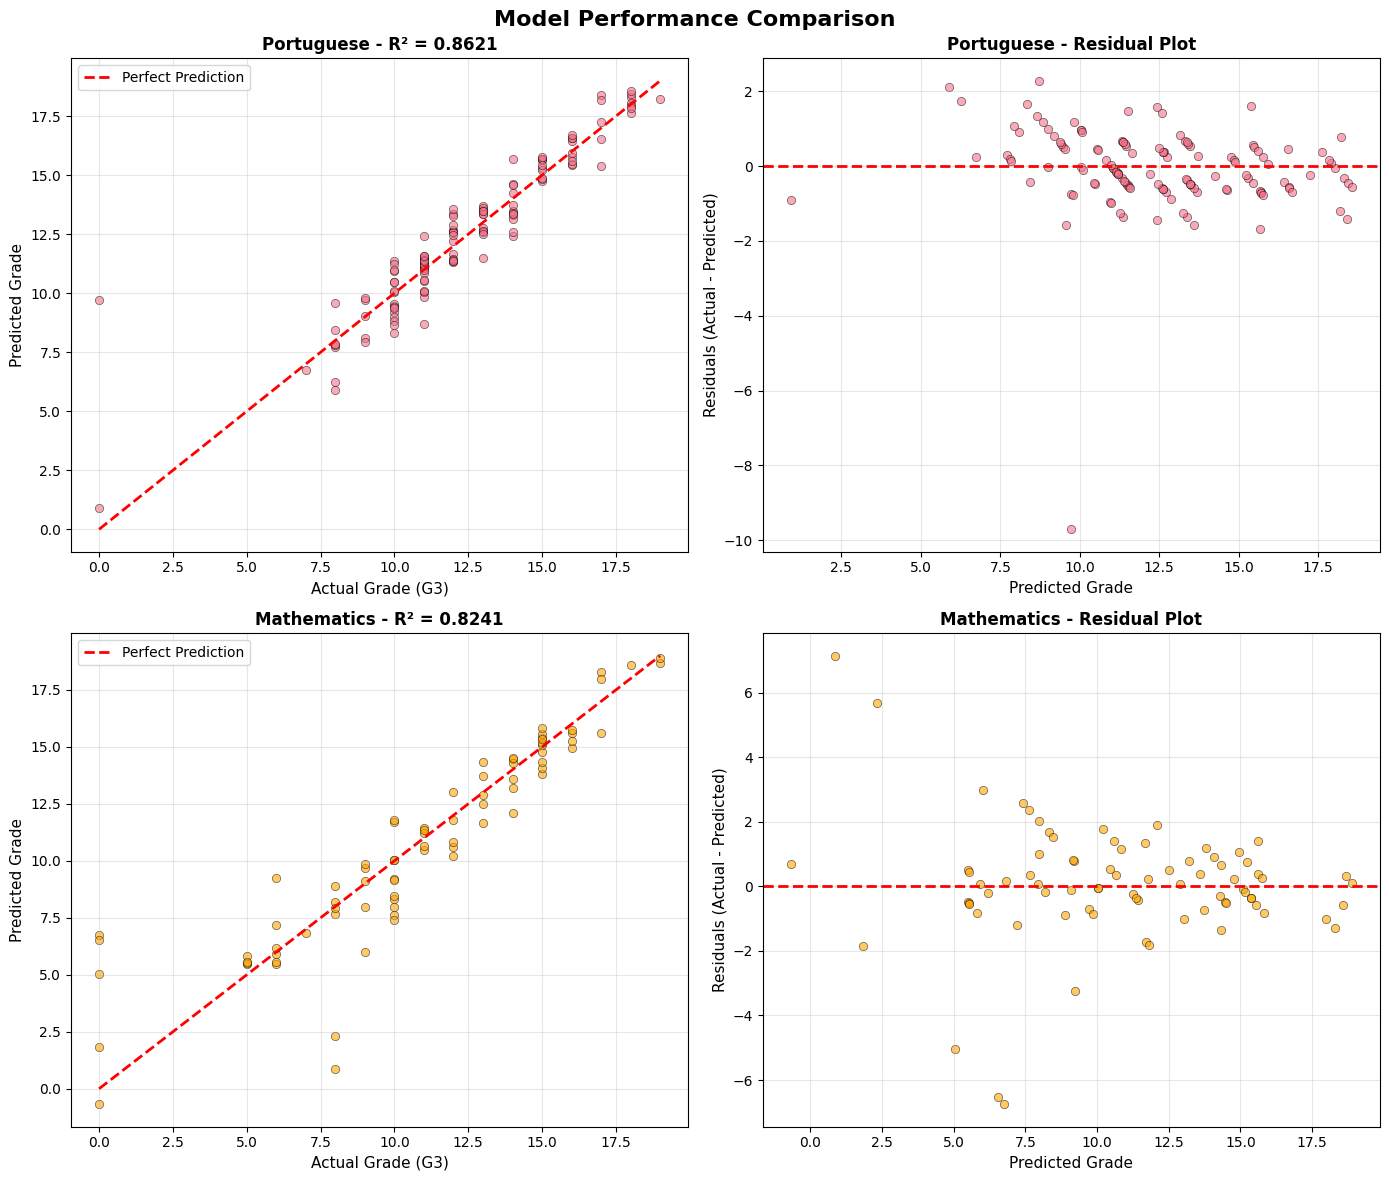

Visualization saved as 'model_performance_comparison.png'


In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold')

axes[0, 0].scatter(y_test_por, y_pred_por, alpha=0.6, edgecolors='k', linewidth=0.5)
axes[0, 0].plot([y_test_por.min(), y_test_por.max()], 
                [y_test_por.min(), y_test_por.max()], 
                'r--', lw=2, label='Perfect Prediction')
axes[0, 0].set_xlabel('Actual Grade (G3)', fontsize=11)
axes[0, 0].set_ylabel('Predicted Grade', fontsize=11)
axes[0, 0].set_title(f'Portuguese - R² = {r2_por:.4f}', fontsize=12, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

residuals_por = y_test_por - y_pred_por
axes[0, 1].scatter(y_pred_por, residuals_por, alpha=0.6, edgecolors='k', linewidth=0.5)
axes[0, 1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0, 1].set_xlabel('Predicted Grade', fontsize=11)
axes[0, 1].set_ylabel('Residuals (Actual - Predicted)', fontsize=11)
axes[0, 1].set_title('Portuguese - Residual Plot', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].scatter(y_test_math, y_pred_math, alpha=0.6, edgecolors='k', linewidth=0.5, color='orange')
axes[1, 0].plot([y_test_math.min(), y_test_math.max()], 
                [y_test_math.min(), y_test_math.max()], 
                'r--', lw=2, label='Perfect Prediction')
axes[1, 0].set_xlabel('Actual Grade (G3)', fontsize=11)
axes[1, 0].set_ylabel('Predicted Grade', fontsize=11)
axes[1, 0].set_title(f'Mathematics - R² = {r2_math:.4f}', fontsize=12, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

residuals_math = y_test_math - y_pred_math
axes[1, 1].scatter(y_pred_math, residuals_math, alpha=0.6, edgecolors='k', linewidth=0.5, color='orange')
axes[1, 1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1, 1].set_xlabel('Predicted Grade', fontsize=11)
axes[1, 1].set_ylabel('Residuals (Actual - Predicted)', fontsize=11)
axes[1, 1].set_title('Mathematics - Residual Plot', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('model_performance_comparison.png', dpi=200, bbox_inches='tight')
plt.show()

print("Visualization saved as 'model_performance_comparison.png'")

### 8.3 Feature Importance Analysis

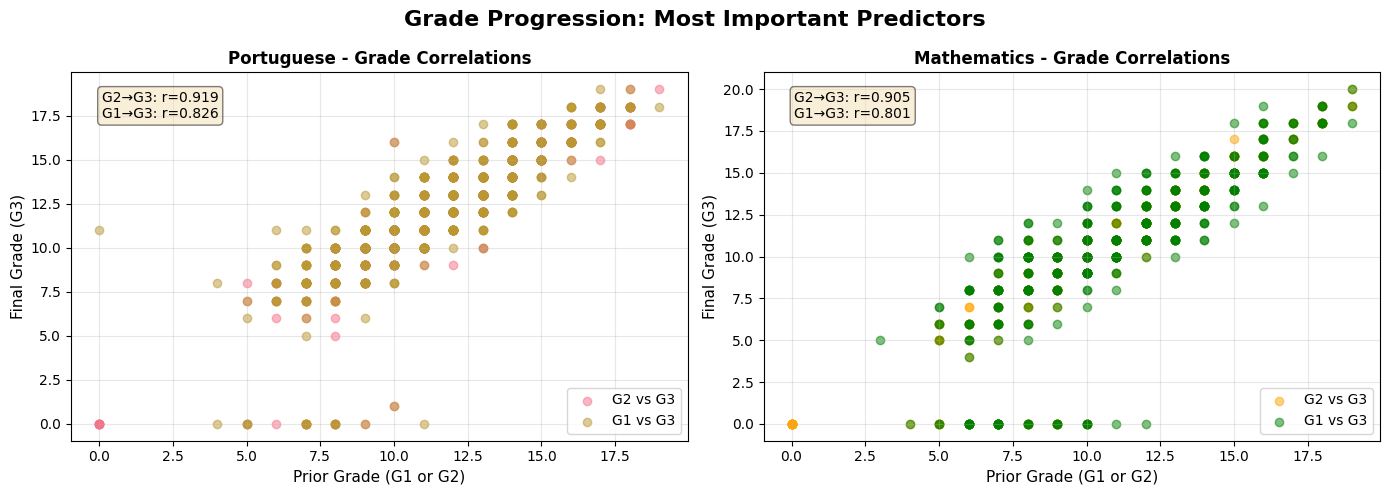

Feature importance visualization saved as 'feature_importance_grades.png'


In [13]:
# Analyze grade correlations (most important features)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Grade Progression: Most Important Predictors', fontsize=16, fontweight='bold')

# Portuguese
axes[0].scatter(df_por['G2'], df_por['G3'], alpha=0.5, label='G2 vs G3')
axes[0].scatter(df_por['G1'], df_por['G3'], alpha=0.5, label='G1 vs G3')
axes[0].set_xlabel('Prior Grade (G1 or G2)', fontsize=11)
axes[0].set_ylabel('Final Grade (G3)', fontsize=11)
axes[0].set_title(f'Portuguese - Grade Correlations', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].text(0.05, 0.95, f"G2→G3: r={df_por['G2'].corr(df_por['G3']):.3f}\nG1→G3: r={df_por['G1'].corr(df_por['G3']):.3f}",
            transform=axes[0].transAxes, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Mathematics
axes[1].scatter(df_math['G2'], df_math['G3'], alpha=0.5, label='G2 vs G3', color='orange')
axes[1].scatter(df_math['G1'], df_math['G3'], alpha=0.5, label='G1 vs G3', color='green')
axes[1].set_xlabel('Prior Grade (G1 or G2)', fontsize=11)
axes[1].set_ylabel('Final Grade (G3)', fontsize=11)
axes[1].set_title(f'Mathematics - Grade Correlations', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].text(0.05, 0.95, f"G2→G3: r={df_math['G2'].corr(df_math['G3']):.3f}\nG1→G3: r={df_math['G1'].corr(df_math['G3']):.3f}",
            transform=axes[1].transAxes, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('feature_importance_grades.png', dpi=200, bbox_inches='tight')
plt.show()

print("Feature importance visualization saved as 'feature_importance_grades.png'")

### 8.4 Academic Factors Impact

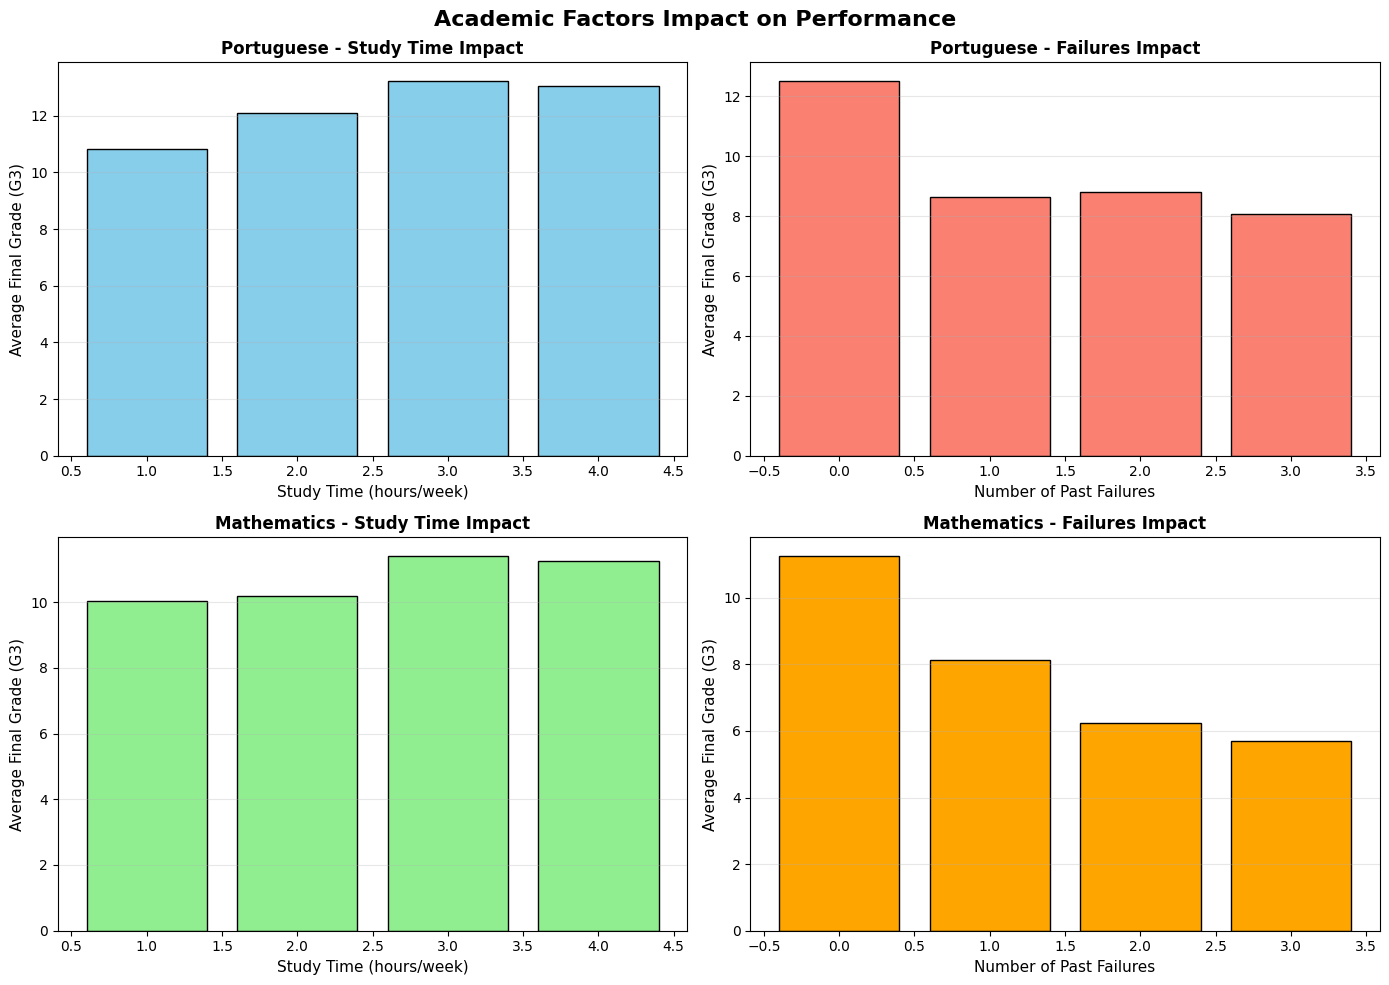

Academic factors visualization saved as 'academic_factors_impact.png'


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Academic Factors Impact on Performance', fontsize=16, fontweight='bold')

study_impact_por = df_por.groupby('studytime')['G3'].mean()
axes[0, 0].bar(study_impact_por.index, study_impact_por.values, color='skyblue', edgecolor='black')
axes[0, 0].set_xlabel('Study Time (hours/week)', fontsize=11)
axes[0, 0].set_ylabel('Average Final Grade (G3)', fontsize=11)
axes[0, 0].set_title('Portuguese - Study Time Impact', fontsize=12, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3, axis='y')

failures_por = df_por.groupby('failures')['G3'].mean()
axes[0, 1].bar(failures_por.index, failures_por.values, color='salmon', edgecolor='black')
axes[0, 1].set_xlabel('Number of Past Failures', fontsize=11)
axes[0, 1].set_ylabel('Average Final Grade (G3)', fontsize=11)
axes[0, 1].set_title('Portuguese - Failures Impact', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3, axis='y')

study_impact_math = df_math.groupby('studytime')['G3'].mean()
axes[1, 0].bar(study_impact_math.index, study_impact_math.values, color='lightgreen', edgecolor='black')
axes[1, 0].set_xlabel('Study Time (hours/week)', fontsize=11)
axes[1, 0].set_ylabel('Average Final Grade (G3)', fontsize=11)
axes[1, 0].set_title('Mathematics - Study Time Impact', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='y')

failures_math = df_math.groupby('failures')['G3'].mean()
axes[1, 1].bar(failures_math.index, failures_math.values, color='orange', edgecolor='black')
axes[1, 1].set_xlabel('Number of Past Failures', fontsize=11)
axes[1, 1].set_ylabel('Average Final Grade (G3)', fontsize=11)
axes[1, 1].set_title('Mathematics - Failures Impact', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('academic_factors_impact.png', dpi=200, bbox_inches='tight')
plt.show()

print("Academic factors visualization saved as 'academic_factors_impact.png'")

## 9. Key Findings & Conclusions

### 9.1 Model Performance

**Predictive Accuracy:**
- Portuguese: 86.19% R² (RMSE: 1.16, MAE: 0.71)
- Mathematics: 82.43% R² (RMSE: 1.90, MAE: 1.18)

Both models exceed the 80% R² threshold, indicating strong predictive power.

### 9.2 Most Important Predictors

**Top 5 Features by Impact:**

1. **G2 (Second Period Grade)** - Correlation: 0.919 (Portuguese), 0.905 (Math)
   - Strongest predictor of final grades
   - Students who perform well mid-term continue to perform well

2. **G1 (First Period Grade)** - Correlation: 0.826 (Portuguese), 0.801 (Math)
   - Early indicator of final performance
   - Enables early intervention for struggling students

3. **Failures (Past Class Failures)**
   - Students with 0 failures score approximately 4 points higher
   - Critical risk factor for underperformance

4. **Study Time**
   - Optimal: 3-4 hours/week
   - Diminishing returns beyond 3 hours

5. **Absences**
   - Higher absences correlate with lower grades
   - Math students have more absences leading to lower performance

### 9.3 Subject-Specific Insights

**Portuguese vs Mathematics:**
- Portuguese is easier (84.6% pass rate vs 67.1%)
- Mathematics has higher variance (σ=4.58 vs σ=3.23)
- Portuguese is more predictable (86.19% R² vs 82.43%)
- Math requires more consistent effort beyond just study time

### 9.4 Practical Applications

**This model can be used for:**
1. **Early Warning System** - Identify at-risk students after G1/G2
2. **Resource Allocation** - Target tutoring to highest-need students
3. **Academic Counseling** - Data-driven study recommendations
4. **Policy Evaluation** - Measure impact of interventions

### 9.5 Model Strengths

**Stacking Ensemble Advantages:**
- Combines 7 diverse algorithms (tree-based, linear, distance-based)
- Reduces variance through intelligent averaging
- Less prone to overfitting than individual models
- Industry-standard technique used in competitions

### 9.6 Limitations

**Considerations:**
- Dataset from Portuguese schools (may not generalize globally)
- Small sample for Math (395 students)
- Requires G1/G2 grades (not useful for first-period predictions)
- Correlational, not causal relationships

---